In [31]:
%load_ext autoreload
%autoreload 2

import numpy as np

from smt.sampling_methods import LHS, Random, FullFactorial
from smt.surrogate_models import KRG, MixIntKernelType

from comcatalyst.vars.var_metadata import VarMetadata
from comcatalyst.vars.vars_metadata import VarsMetadata
from comcatalyst.xprs.fn_objectives import calc_gp_objective_01
from comcatalyst.xprs.xpr_moda import XPRModA
from comcatalyst.xprs.visualizations import (
    plot_comparison_convergence, 
    plot_gp_quant_by_qual, 
    plot_3d_gp_quant_by_qual,
    plot_ground_truth,
    plot_3d_ground_truth
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **XPR**

In [32]:
# Variables
vars_metadata = VarsMetadata([
    VarMetadata(name="x_qual1",  var_type="categorical", support=["A","B"]),
    VarMetadata(name="x_qual2",  var_type="categorical", support=["alpha","beta"]),
    VarMetadata(name="x_quant1", var_type="continuous",  support=(-1, 1)),
    VarMetadata(name="x_quant2", var_type="continuous",  support=(-1, 1)),
])

z = {"z1": 1.0, "z2": 1.0}

In [46]:
# Hyperparameters
fn_gp_objective = lambda x, vars_metadata, z, sigma_noise, rng=None: calc_gp_objective_01(
    x=x,
    vars_metadata=vars_metadata,
    z=z,
    sigma_noise=sigma_noise,
    rng=rng,
    _SCALE_Q1={0: 2, 1: 2},
    _SCALE_Q2={0: 2, 1: 2},
)

n_init = 2
n_iter_bo = 28
n_start = 20
sampling_method = LHS
kernel = MixIntKernelType.CONT_RELAX
sampling_criterion = "ese"
bo_criterion = "EI"
sigma_noise = 0.1
qei="KBLB"
seed = 0
seed_ydoe_offset = 1000

In [34]:
# True max
x_true_max, y_true_max, _, _ = XPRModA.calc_true_max(
    fn_gp_objective=fn_gp_objective, 
    vars_metadata=vars_metadata, 
    z=z, 
    n_grille=1000
)

XPRModA.print_opt_result(x=x_true_max, y=y_true_max, vars_metadata=vars_metadata)

  x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.4935 / x_quant2 = 0.9980
  y* = 5.2992


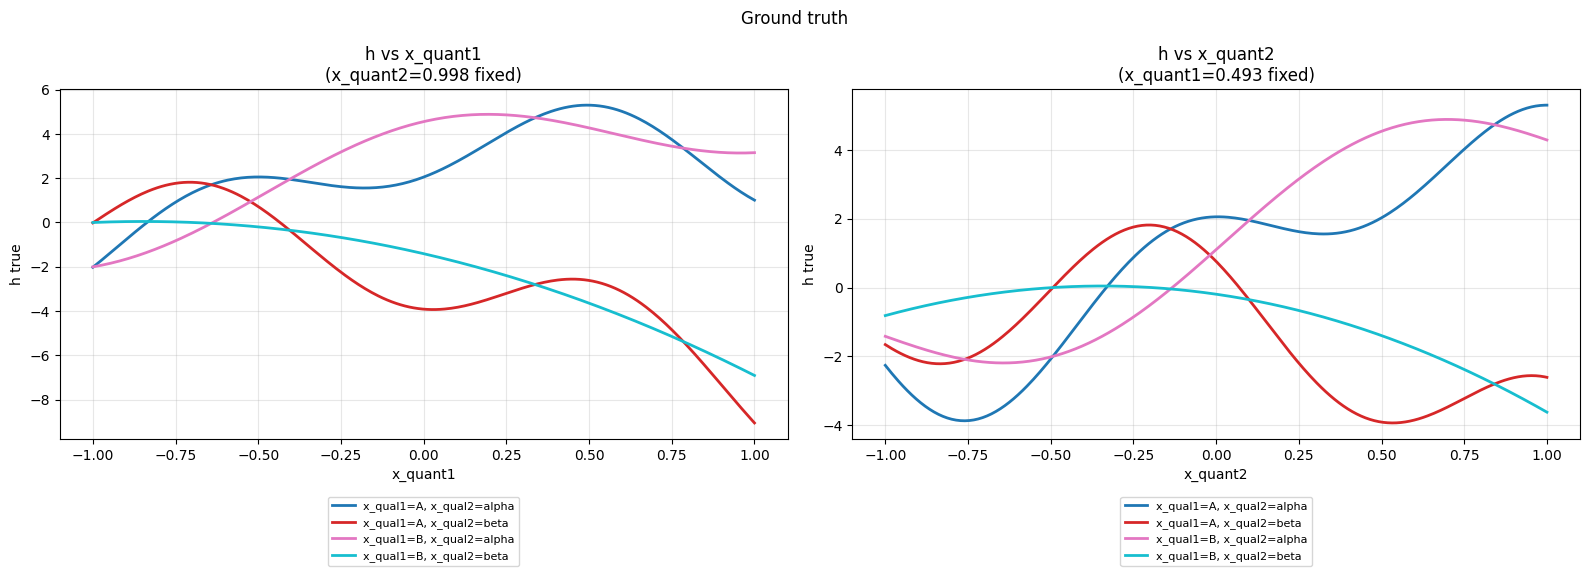

In [35]:
# Plot true max 2d
plot_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_fixed_vals=(
        (2, x_true_max[2]), 
        (3, x_true_max[3])
    ),
    n_points=300,
    figsize=(8,6)
)

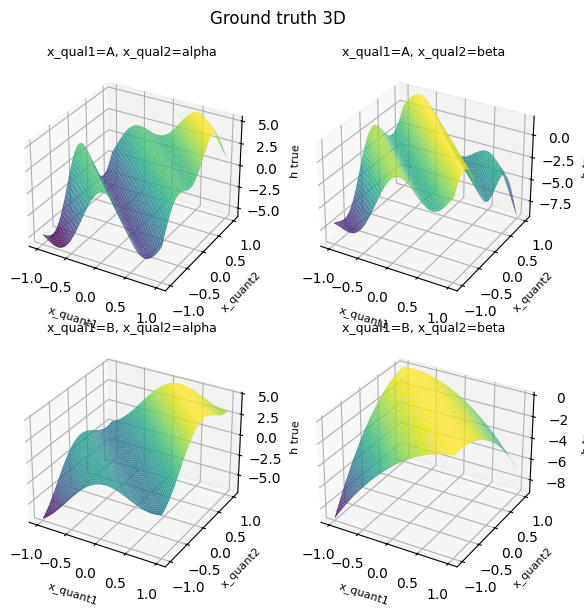

In [36]:
# PLot true max 3d
plot_3d_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_idx_1=2,
    quant_idx_2=3,
    n_points=300,
    n_cols=2,
    figsize=(3,3)    
)


In [50]:
# EGO
design_space = XPRModA.create_smt_design_space(
    vars_metadata=vars_metadata,
    sampling_method=sampling_method,
    sampling_criterion=sampling_criterion,
    seed=seed
)

x_init = XPRModA.calc_x_init(
    n_init=n_init,
    design_space=design_space,
    sampling_method=sampling_method,
    sampling_criterion=sampling_criterion,
    seed=seed
)

y_init = XPRModA.calc_y_objective_for_ego(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    x=x_init, 
    z=z,
    sigma_noise=sigma_noise, 
    rng=np.random.default_rng(seed+seed_ydoe_offset)
)

res_ego = XPRModA.run_ego(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    design_space=design_space,
    x_init=x_init,
    y_init=y_init,
    z=z,
    n_iter_bo=n_iter_bo,
    kernel=kernel,
    bo_criterion=bo_criterion,
    qei=qei,
    sigma_noise=sigma_noise,
    n_start=n_start,
    seed=seed
)

In [52]:
# EGO results details
print(f"--- BO x_data ---\n{res_ego.x_data}")
print(f"\n--- BO y_data ---\n{res_ego.y_data}")

print("\n--- Results ---")
XPRModA.print_opt_result(x=res_ego.x_opt, y=res_ego.y_opt, vars_metadata=vars_metadata)

--- BO x_data ---
[[ 0.          0.         -0.18672976 -0.08724442]
 [ 1.          1.          0.81585355  0.0027385 ]
 [ 1.          1.          0.45405374 -0.01939977]
 [ 1.          1.         -0.19088806 -0.05874322]
 [ 0.          1.          0.41389327  0.90075259]
 [ 1.          1.          0.18850401  1.        ]
 [ 1.          1.          0.25697039 -0.15028602]
 [ 1.          0.          0.18477269  0.02615264]
 [ 1.          1.          0.18650131  0.0215379 ]
 [ 0.          1.          1.         -1.        ]
 [ 0.          0.          1.         -1.        ]
 [ 0.          1.          0.51944574 -1.        ]
 [ 0.          1.          1.         -0.59171556]
 [ 0.          1.          1.         -0.33908282]
 [ 1.          1.         -0.4090229   0.42947836]
 [ 0.          1.          1.         -0.70859145]
 [ 1.          1.          0.46999762 -0.84597037]
 [ 1.          0.          0.19737411 -0.66336945]
 [ 1.          1.          1.         -0.60446691]
 [ 1.        

In [23]:
# Check repartition qualitative variables
for q1 in [0, 1]:
    for q2 in [0, 1]:
        mask = (res_ego.x_data[:n_init,0]==q1) & (res_ego.x_data[:n_init,1]==q2)
        print(f"qual1={q1} qual2={q2}: {mask.sum()} points")

qual1=0 qual2=0: 1 points
qual1=0 qual2=1: 2 points
qual1=1 qual2=0: 2 points
qual1=1 qual2=1: 0 points


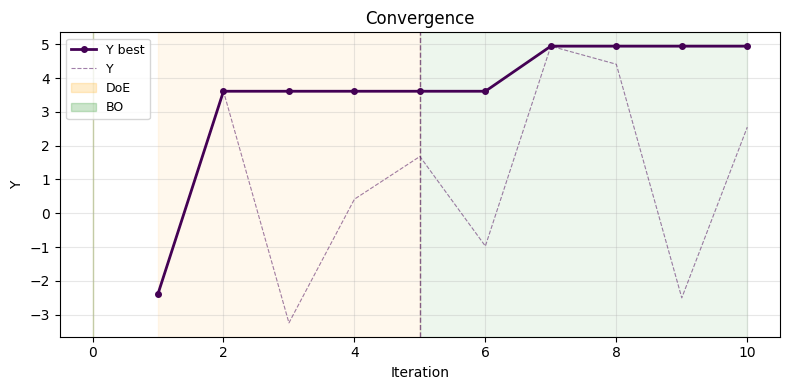

In [24]:
# Plot convergence
plot_comparison_convergence(
    y_datas=[res_ego.y_data],
    n_init=n_init,
)

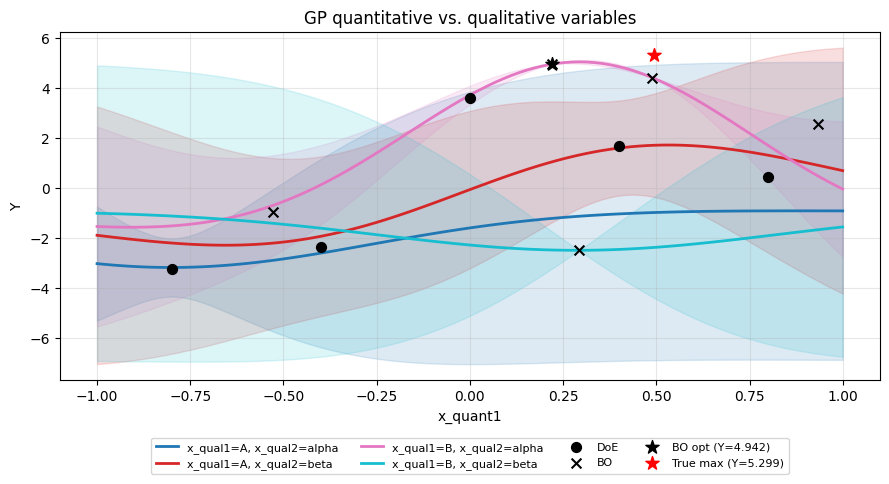

In [25]:
# Plot quant1 by qual
plot_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx=2,
    min_optim=True,
    qual_filter=[(0, ["A", "B"]), (1, ["alpha", "beta"])],
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    figsize=(9,5)
)

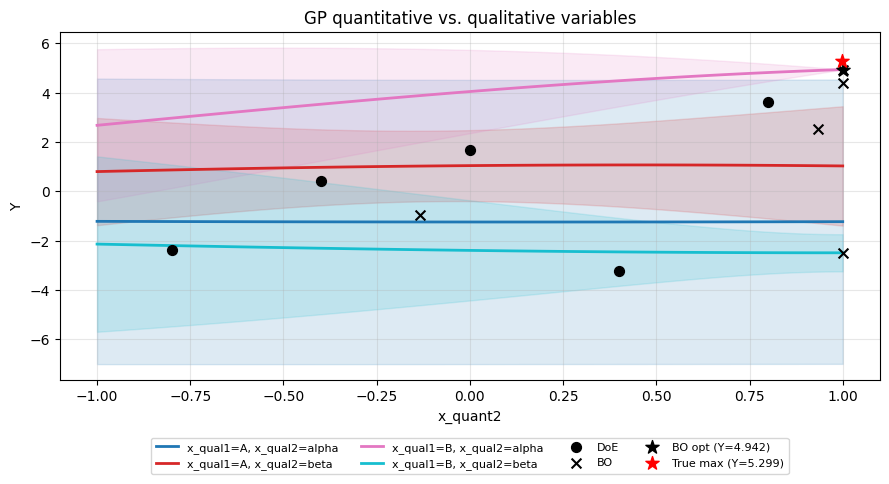

In [19]:
# Plot quant2 by qual
plot_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx=3,
    min_optim=True,
    qual_filter=[(0, ["A", "B"]), (1, ["alpha", "beta"])],
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max    
)

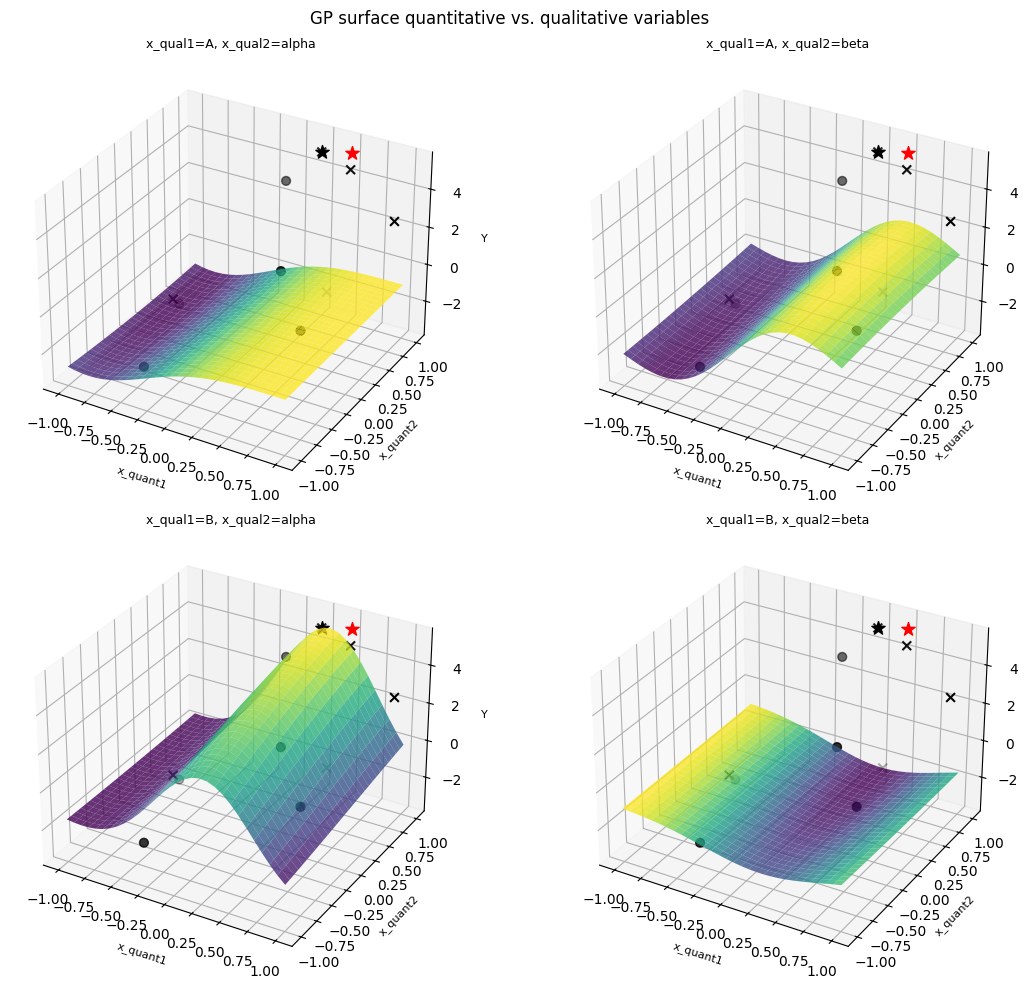

In [20]:
# Plot 3d
plot_3d_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx_1=2,
    quant_to_variate_idx_2=3,
    min_optim=True,
    qual_filter=None,
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    n_cols=2
)